<a href="https://colab.research.google.com/github/Grashch/Kaggle_tasks/blob/main/SHAP_Values.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Объяснение методов библиотеки Shap**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt


In [ ]:
# 1. Создаём данные (продолжение)
np.random.seed(42)
data = pd.DataFrame({
    'Дождь_мм': np.random.normal(60, 20, 100),
    'Температура_C': np.random.normal(22, 4, 100),
    'Удобрения_кг': np.random.uniform(0, 150, 100),
    'Кислотность_pH': np.random.uniform(5.5, 7.5, 100),
    'Площадь_га': np.random.uniform(1, 10, 100),
    'Сорт_семян': np.random.randint(1, 6, 100)
})

# Целевая переменная (урожайность) с нелинейными зависимостями
data['Урожайность_т'] = (
    0.4 * data['Дождь_мм'] +
    -0.2 * (data['Температура_C'] - 22)**2 +  # оптимум при 22 °C
    1.2 * data['Удобрения_кг'] +
    -1.0 * (data['Кислотность_pH'] - 6.5)**2 +  # оптимум при pH 6.5
    0.1 * data['Площадь_га'] +
    2.0 * data['Сорт_семян'] +
    np.random.normal(0, 3, 100)  # шум
)

# Разделяем признаки и цель
X = data.drop('Урожайность_т', axis=1)
y = data['Урожайность_т']

In [ ]:
# 2. Обучаем модель
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X, y)

RandomForestRegressor(n_estimators=50, random_state=42)

In [ ]:
# 3. Создаём SHAP‑эксплайнер
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

In [ ]:
# Базовый уровень (средний прогноз)
expected_value = explainer.expected_value.item()
expected_value

114.91751714313318

# **Применение основных методов SHAP**

1. **summary_plot** — общая важность признаков

/tmp/ipython-input-321775720.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, plot_type='bar', show=False) # 'show=False' предотвращает автоматический показ


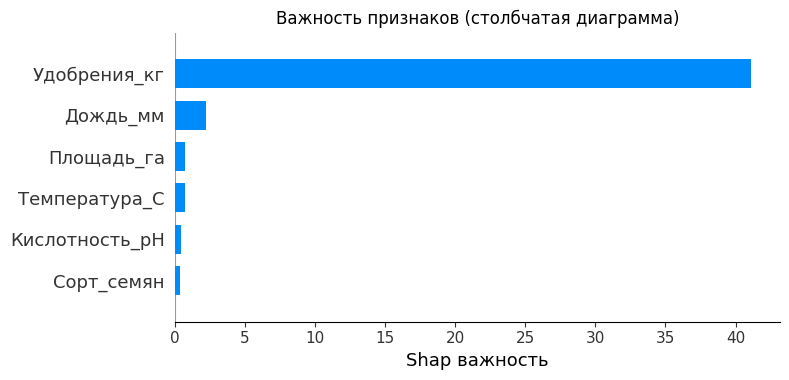

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X, plot_type='bar', show=False) # 'show=False' предотвращает автоматический показ
plt.title('Важность признаков (столбчатая диаграмма)')
plt.xlabel('Shap важность')
plt.tight_layout() # Автоматически подгоняет расположение элементов, чтобы заголовок не обрезался
plt.show()

/tmp/ipython-input-1690304101.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, show=False)


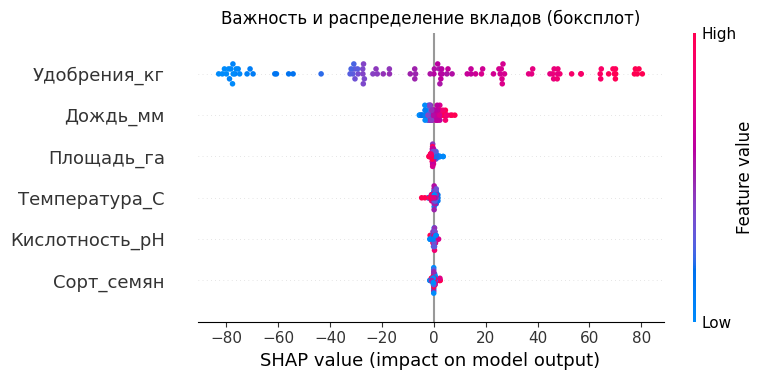

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X, show=False)
plt.title("Важность и распределение вкладов (боксплот)")
plt.tight_layout() # Автоматически подгоняет расположение элементов, чтобы заголовок не обрезался
plt.show()

Что увидим:
*   Столбчатая диаграмма: самые высокие столбцы — самые важные признаки. Например, «Удобрения_кг» и «Сорт_семян» могут быть вверху.
*   Боксплот:


    *   Широкие «усы» → признак сильно варьируется по влиянию.
    *   Смещение точек влево/вправо → преобладает отрицательное/положительное   влияние.
    *   Цвет точек (по значению признака) → например, высокие значения «Кислотности_pH» чаще дают отрицательный вклад.

2. **dependence_plot** — анализ взаимодействия признаков

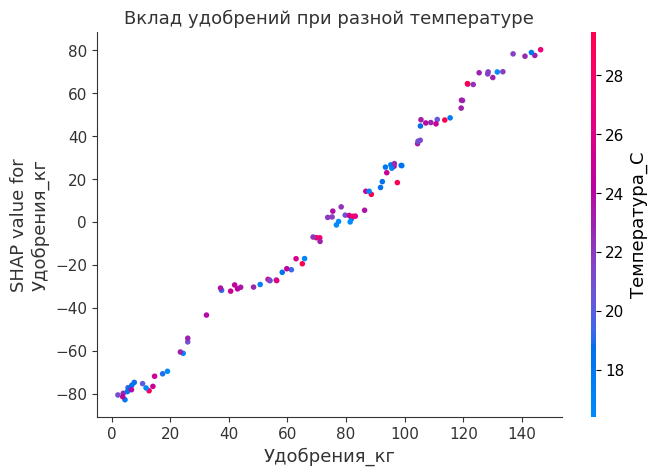

In [ ]:
# Как «Удобрения_кг» влияют на прогноз при разной температуре
shap.dependence_plot(
    "Удобрения_кг",
    shap_values,
    X,
    interaction_index="Температура_C",
    title="Вклад удобрений при разной температуре"
)
plt.show()

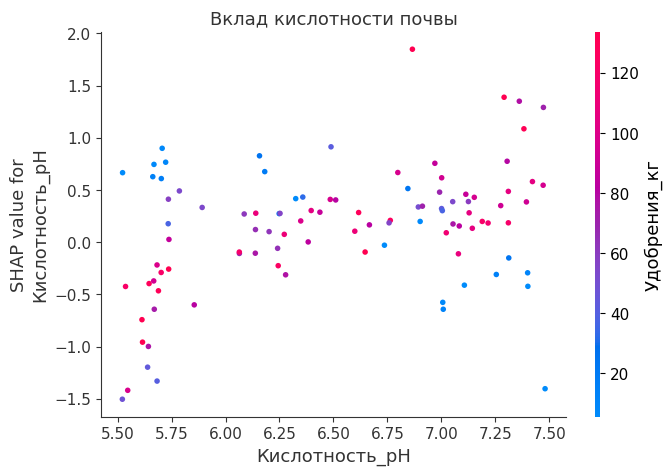

In [ ]:
# Как «Кислотность_pH» влияет на прогноз
shap.dependence_plot(
    "Кислотность_pH",
    shap_values,
    X,
    title="Вклад кислотности почвы"
)
plt.show()

Как читать:
*   По горизонтали: значение анализируемого признака (например, кг удобрений).
*   По вертикали: SHAP‑значение (вклад в урожайность).
*   Цвет точек: значение второго признака (например, температура).

Пример выводов:
*   Если для высокой температуры (красные точки) линия идёт круче → удобрения эффективнее в тёплую погоду.
*   Если график «Кислотности_pH» имеет U‑образную форму → есть оптимальный уровень pH (около 6.5), где вклад максимален.

3. **force_plot** — объяснение прогноза для одного объекта

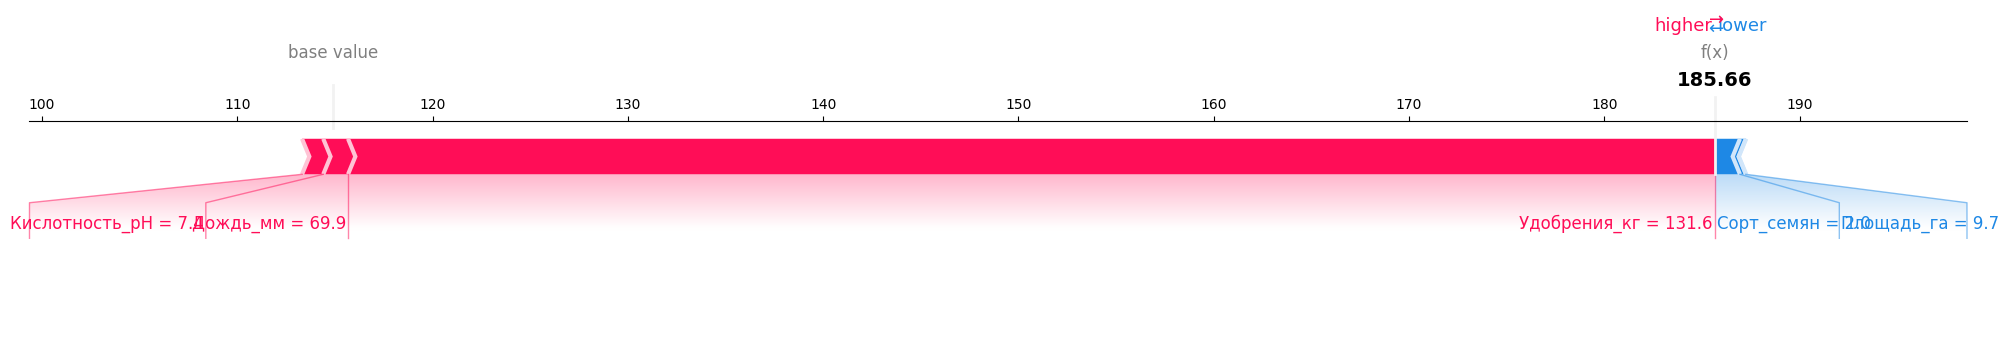

In [ ]:
# Выбираем первый объект из тестовой выборки
data_for_prediction = X.iloc[0:1]
shap_values_single = explainer.shap_values(data_for_prediction)
data_for_prediction = data_for_prediction.round(1)

shap.force_plot(
    expected_value,
    shap_values_single,
    data_for_prediction,
    matplotlib=True,
    figsize=(25, 3)
)
plt.show()


Что увидим:
*   Слева: базовый уровень (средняя урожайность по всем полям, например, 45 т/га).
*   Стрелки вправо (красные): признаки, повышающие прогноз. Например:
    *   «Удобрения_кг»: +8.2 т
    *   «Сорт_семян»: +5.1 т
*   Стрелки влево (синие): признаки, снижающие прогноз. Например:
    *   «Температура_C»: −3.4 т (было слишком жарко)
    *   «Кислотность_pH»: −2.1 т (pH далёк от оптимума)
*   Итоговый прогноз: 45 + 8.2 + 5.1 − 3.4 − 2.1 = 52.8 т/га

4. **waterfall_plot** — пошаговый разбор вклада признаков

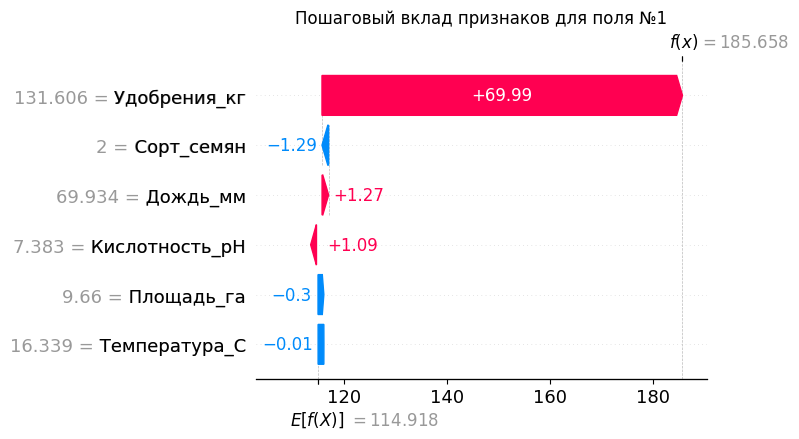

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],  # вклады для первого объекта
        base_values=expected_value,
        data=X.iloc[0],
        feature_names=X.columns
    ),
    max_display=10,
    show=False
)
plt.title("Пошаговый вклад признаков для поля №1")
plt.tight_layout()
plt.show()

Как читать:
1.   Начальная точка: базовый уровень (45 т/га).
2.   Каждая ступенька: добавление вклада одного признака. Например:
  *   +8.2 т от «Удобрений_кг» → 53.2 т
  *   −3.4 т от «Температура_C» → 49.8 т
  *   и т. д.
3.   Финальная точка: итоговый прогноз (52.8 т/га).

Польза: видно, какие признаки «перевешивают» и как они компенсируют друг друга.

5. **decision_plot** — сравнение нескольких прогнозов

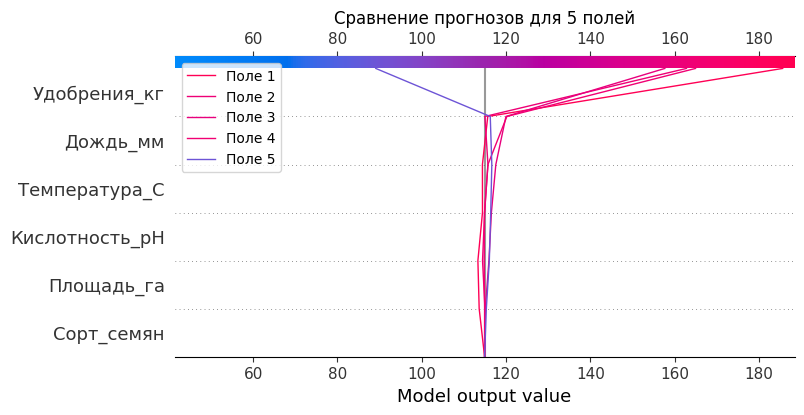

In [ ]:
feature_names=X.columns
shap.decision_plot(
    expected_value,
    shap_values[:5],  # прогнозы для первых 5 объектов
    feature_names,
    feature_order='importance',  # сортировка по важности
    link='identity',
    legend_labels=['Поле 1', 'Поле 2', 'Поле 3', 'Поле 4', 'Поле 5'],
    title="Сравнение прогнозов для 5 полей"
)
plt.show()

Что видим:
*   5 линий: каждая — траектория прогноза для одного поля.
*   Горизонтальная ось: вклад признаков (от базового уровня к итогу).
*   Вертикальная ось: признаки, упорядоченные по важности.
*   Пересечения линий: где прогнозы начинают различаться.

Пример вывода:

*   Если линии расходятся на «Удобрения_кг» → именно этот признак сильнее всего различает поля.
*   Если все линии идут параллельно на «Площадь_га» → этот признак мало влияет на разницу прогнозов.

# Итоговые выводы по примеру


1.   **summary_plot** показал:


*   Самые важные признаки: «Удобрения_кг», «Сорт_семян», «Температура_C».
*   «Площадь_га» почти не влияет (низкий столбец).


2.   **dependence_plot** выявил:


*   Взаимодействие «Удобрения × Температура»: в жару удобрения работают хуже.

## **Домашнее задание по теме Shap из Kaggle**

# **Шаг 1**
Вы создали простую модель, но врачи говорят, что не знают, как оценить модель, и хотели бы, чтобы вы показали им доказательства того, что модель работает в соответствии с их медицинской интуицией. Создайте какие-нибудь графики или таблицы, которые позволят им быстро оценить работу модели?

Они очень заняты. Поэтому они хотят, чтобы вы сжали обзор вашей модели до 1 или 2 графиков, а не до длинной цепочки графиков.

Мы начнем после того, как вы создадите базовую модель. Просто запустите следующую ячейку, чтобы создать модель с именем my_model.

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

data = pd.read_csv('/content/hospital-readmissions_train.csv')
y = data.readmitted
base_features = [c for c in data.columns if c != 'readmitted']
X = data[base_features]
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=20)
my_model = RandomForestClassifier(n_estimators=30, random_state=1).fit(train_X, train_y)

In [ ]:
!pip install eli5

In [ ]:
import eli5
from eli5.sklearn import PermutationImportance

perm = PermutationImportance(my_model, random_state=3).fit(val_X, val_y)
eli5.show_weights(
    perm,
    feature_names=val_X.columns.tolist(),
    top=64
    )

Weight,Feature
0.0475 ± 0.0026,number_inpatient
0.0111 ± 0.0034,number_outpatient
0.0103 ± 0.0033,number_emergency
0.0091 ± 0.0059,time_in_hospital
0.0075 ± 0.0040,number_diagnoses
0.0057 ± 0.0027,diag_1_428
0.0056 ± 0.0073,num_medications
0.0051 ± 0.0054,num_lab_procedures
0.0041 ± 0.0052,num_procedures
0.0039 ± 0.0061,medical_specialty_?


# **Шаг 2**
Похоже, что параметр number_inpatient действительно очень важен. Врачи хотели бы узнать о нём больше. Создайте для них график, показывающий, как num_inpatient влияет на прогнозы модели.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

feature_name = 'number_inpatient'
PartialDependenceDisplay.from_estimator(my_model, val_X, [feature_name])
plt.tight_layout()
plt.show()

# **Шаг 3**
Врачи считают, что увеличение количества стационарных процедур приводит к повышению точности прогнозов — это хороший знак. Но по этому графику они не могут определить, насколько велико или мало это изменение. Они хотели бы, чтобы вы создали аналогичный график для параметра time_in_hospital, чтобы сравнить результаты.

In [ ]:
feature_name = 'time_in_hospital'
PartialDependenceDisplay.from_estimator(my_model, val_X, [feature_name])
plt.tight_layout()
plt.show()

# **Шаг 4**

Ух ты! Похоже, time_in_hospital вообще не имеет значения. Разница между самым низким и самым высоким значением на графике частичной зависимости составляет около 5%.

Если ваша модель пришла к такому выводу, врачи ей поверят. Но это кажется таким низким показателем. Может быть, данные неверны, или ваша модель делает что-то более сложное, чем они ожидают?

Они хотели бы, чтобы вы показали им исходный показатель повторной госпитализации для каждого значения time_in_hospital, чтобы сравнить его с графиком частичной зависимости.


*   Создайте этот график.
*   Результаты похожи или отличаются?

In [ ]:
all_train = pd.concat([train_X, train_y], axis=1)
all_train.groupby(['time_in_hospital']).mean().readmitted.plot()
plt.show()

# **Шаг 5**

Теперь врачи убеждены, что у вас есть правильные данные, и общий обзор модели выглядит разумным. Пришло время превратить это в готовый продукт, который они смогут использовать. В частности, больница хочет, чтобы вы создали функцию patient_risk_factors, которая выполняет следующие действия:

*   Принимает одну строку с данными пациента (в том же формате, что и ваши исходные данные).
*   Создает визуализацию, показывающую, какие характеристики этого пациента повышали риск повторной госпитализации, какие снижали его и насколько эти характеристики имели значение.

Необязательно показывать каждую характеристику с каждым мельчайшим влиянием на риск повторной госпитализации. Достаточно сосредоточиться только на самых важных характеристиках для этого пациента.

In [ ]:
estimater = shap.TreeExplainer(my_model)
shap_values = estimater.shap_values(val_X)
expected_value = explainer.expected_value.item()

# data_for_prediction = val_X.iloc[0:1]

# shap_values_single = explainer.shap_values(data_for_prediction)
# data_for_prediction = data_for_prediction.round(1)

# shap.force_plot(
#     expected_value,
#     shap_values_single,
#     data_for_prediction,
#     matplotlib=True,
#     figsize=(25, 3)
# )
# plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data = pd.read_csv('/content/FIFA 2018 Statistics.csv')
y = (data['Man of the Match'] == "Yes")  # Convert from string "Yes"/"No" to binary
feature_names = [i for i in data.columns if data[i].dtype in [np.int64, np.int64]]
X = data[feature_names]
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)
my_model = RandomForestClassifier(random_state=0).fit(train_X, train_y)

In [ ]:
train_X.shape, val_X.shape

((96, 18), (32, 18))

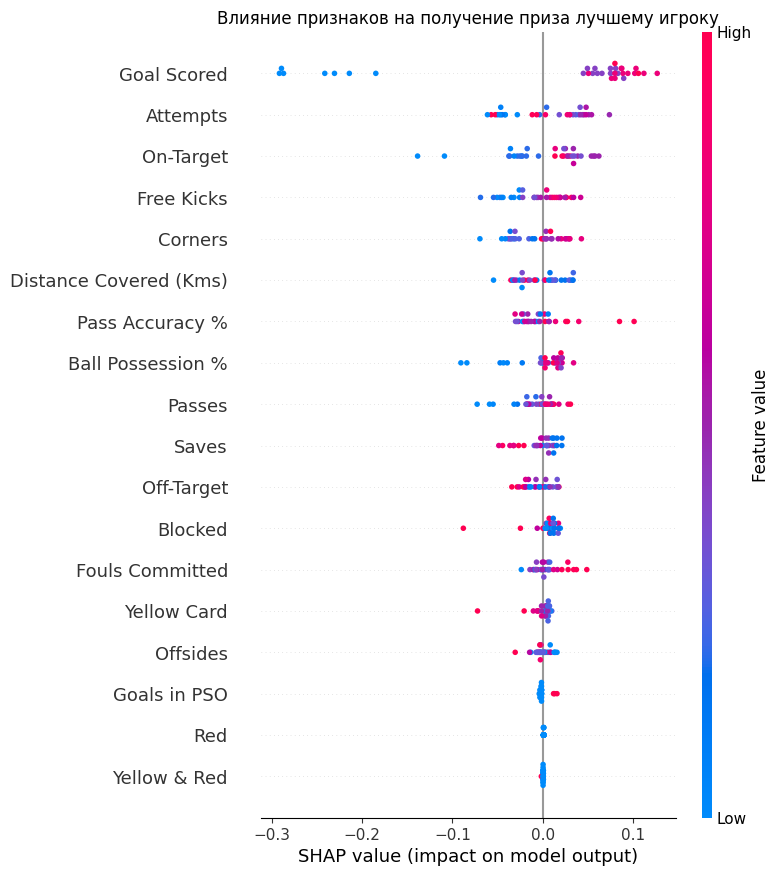

In [ ]:
# 1. Создаем эксплейнер
explainer = shap.TreeExplainer(my_model)

# 2. Получаем значения (для надежности без индекса [1] сразу)
shap_values = explainer.shap_values(val_X)

# 1. Извлекаем вклады только для положительного класса (индекс 1)
# Поскольку у вас (32, 18, 2), нам нужны все строки, все признаки и второй слой
values_to_plot = shap_values[:, :, 1]

# 2. Отрисовка
# В Colab лучше сначала вызвать сам плот без предварительного создания figure,
# либо передать отрисовку явно.
shap.summary_plot(values_to_plot, val_X, show=False)

# 3. Настройка заголовка и отображение
plt.title("Влияние признаков на получение приза лучшему игроку")
plt.show()

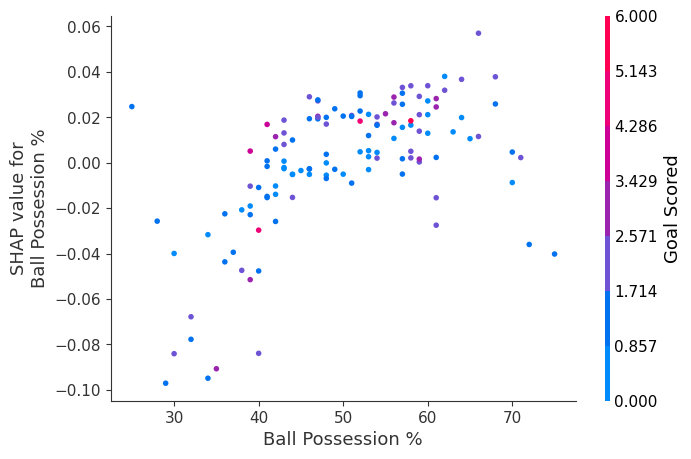

In [ ]:
# Инициализируем инструмент объяснения, оптимизированный для деревьев (XGBoost, Random Forest и др.)
explainer = shap.TreeExplainer(my_model)

# Рассчитываем вклады (SHAP values) для всех признаков в наборе данных X
shap_values = explainer.shap_values(X)

# Выделяем из 3D-массива (объекты, признаки, классы) срез для целевого класса (победа/Class 1)
dependence_plot_values = shap_values[:,:,1]

# Строим график зависимости: как владение мячом влияет на прогноз с учетом количества забитых голов
shap.dependence_plot('Ball Possession %', dependence_plot_values, X, interaction_index="Goal Scored")


# **Д.з. по shap из Kaggle**

In [6]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap

data = pd.read_csv('/content/hospital_readmissions_train.csv')
y = data.readmitted
base_features = ['number_inpatient', 'num_medications', 'number_diagnoses', 'num_lab_procedures',
                 'num_procedures', 'time_in_hospital', 'number_outpatient', 'number_emergency',
                 'gender_Female', 'payer_code_?', 'medical_specialty_?', 'diag_1_428', 'diag_1_414',
                 'diabetesMed_Yes', 'A1Cresult_None']


X = data[base_features].astype(float)

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)


small_val_X = val_X.iloc[:150]
my_model = RandomForestClassifier(n_estimators=30, random_state=1).fit(train_X, train_y)

In [4]:
data.describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted
count,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000
mean,4.395640,42.96012,1.341080,15.988440,0.365920,0.203280,0.64300,7.420160,0.456400
std,2.991165,19.76881,1.705398,8.107743,1.224419,0.982973,1.26286,1.940932,0.498105
min,1.000000,1.00000,0.000000,1.000000,0.000000,0.000000,0.00000,1.000000,0.000000
25%,2.000000,31.00000,0.000000,10.000000,0.000000,0.000000,0.00000,6.000000,0.000000
50%,4.000000,44.00000,1.000000,15.000000,0.000000,0.000000,0.00000,8.000000,0.000000
75%,6.000000,57.00000,2.000000,20.000000,0.000000,0.000000,1.00000,9.000000,1.000000
max,14.000000,126.00000,6.000000,81.000000,36.000000,64.000000,21.00000,16.000000,1.000000


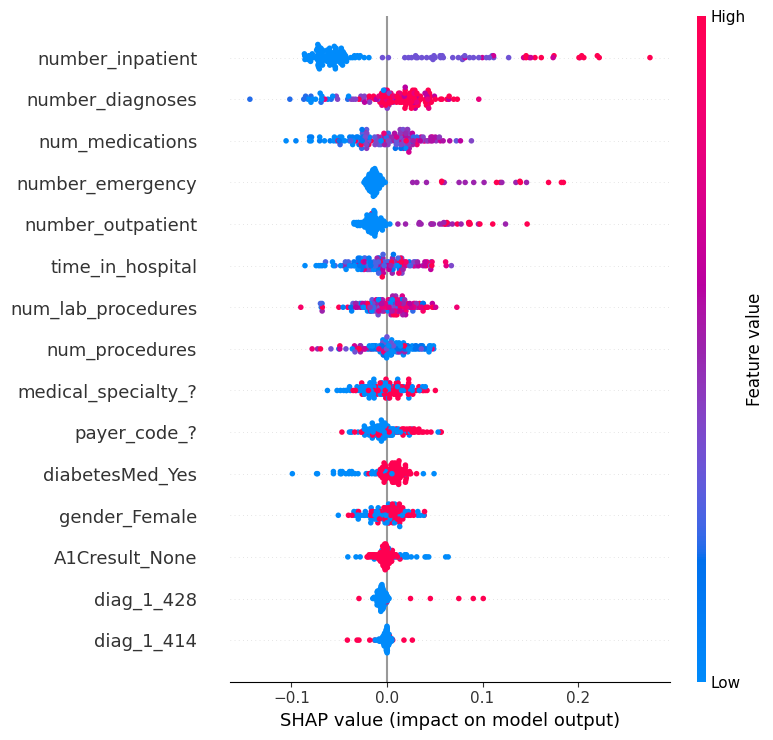

In [5]:
explainer = shap.TreeExplainer(my_model)
shap_values = explainer.shap_values(small_val_X)

shap.summary_plot(shap_values[:,:,1], small_val_X)